Step 1: Environment Setup and Libraries

In [ ]:
!pip install networkx matplotlib pandas seaborn scikit-learn --quiet
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os


Step 2: Load and Explore the Dataset

1. Unzip the Dataset

In [1]:
import zipfile
import os

# Unzip fb100.zip
zip_path = '/content/fb100.zip'
extract_dir = '/content/fb100'
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Files extracted.")


Files extracted.


2. List Available .gml Files



In [ ]:
# List .gml files
gml_dir = '/content/fb100/data/'
mat_files = [f for f in os.listdir(gml_dir) if f.endswith('.gml')]
print("Available .gml files:")
print(mat_files[:5])  # Display first 5 for sanity check


Available .gml files:
['Reed98.gml', 'BU10.gml', 'Santa74.gml', 'BC17.gml', 'UNC28.gml']


# Question 2(a): Degree Distribution



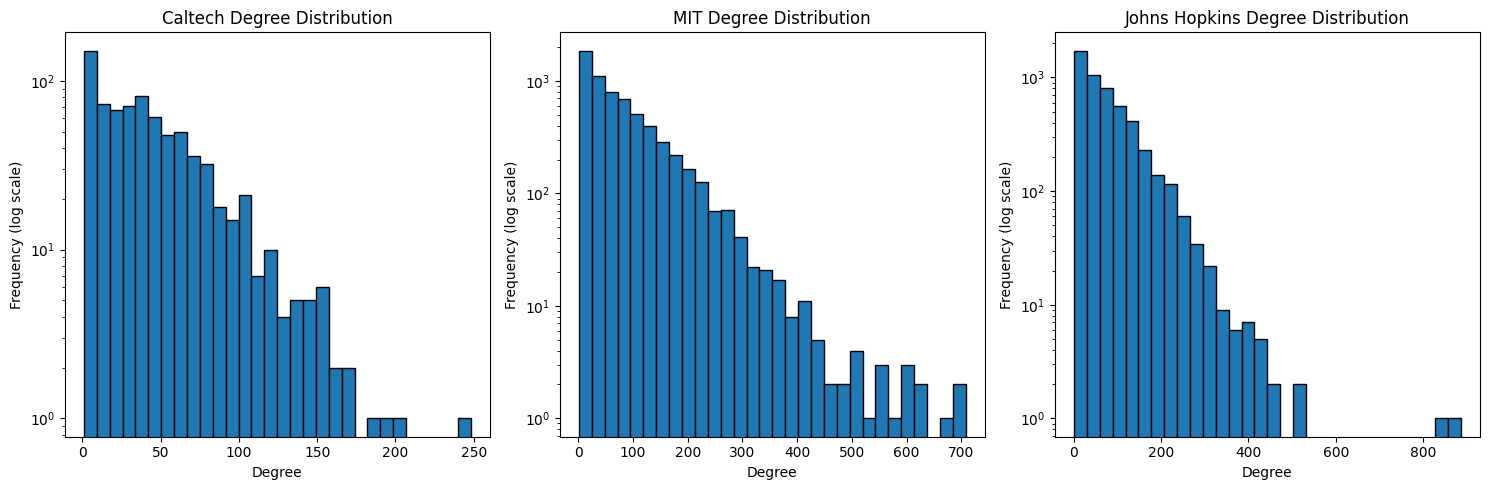

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import os
from collections import Counter

# Define path to your .gml files
gml_dir = '/content/fb100/data/'
networks = {
    'Caltech': 'Caltech36.gml',
    'MIT': 'MIT8.gml',
    'Johns Hopkins': 'Johns Hopkins55.gml'
}

# Plot degree distributions
plt.figure(figsize=(15, 5))

for i, (name, file) in enumerate(networks.items(), 1):
    path = os.path.join(gml_dir, file)
    G = nx.read_gml(path, label='id')
    degrees = [d for _, d in G.degree()]

    plt.subplot(1, 3, i)
    plt.hist(degrees, bins=30, edgecolor='black', log=True)
    plt.title(f'{name} Degree Distribution')
    plt.xlabel('Degree')
    plt.ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()


### Conclusion (Q2a): Degree Distribution

- All three networks show **heavy-tailed** degree distributions — most users have few friends, but a few have many (hubs).
- **Caltech** has a smaller range of degrees (max ~250), reflecting its smaller size.
- **MIT** and **Johns Hopkins** have broader distributions with more high-degree nodes, due to larger, more connected populations.
- These patterns are typical of social networks and suggest **scale-free** structure with heterogeneous connectivity.

# Question2(b):

In [ ]:
results = []

for name, file in networks.items():
    G = nx.read_gml(os.path.join(gml_dir, file), label='id')

    global_clustering = nx.transitivity(G)  # Global clustering coefficient
    mean_local_clustering = nx.average_clustering(G)  # Mean local clustering
    density = nx.density(G)  # Edge density

    results.append({
        'Network': name,
        'Global Clustering': round(global_clustering, 4),
        'Mean Local Clustering': round(mean_local_clustering, 4),
        'Edge Density': round(density, 6)
    })

df_results = pd.DataFrame(results)
df_results

,Network,Global Clustering,Mean Local Clustering,Edge Density
0,Caltech,0.2913,0.4093,0.056404
1,MIT,0.1803,0.2712,0.012118
2,Johns Hopkins,0.1932,0.2684,0.013910


### Conclusion (Q2b): Sparsity and Graph Topology

- All three networks are **sparse** — edge densities are well below 0.1.
- **Caltech** is the densest, likely due to its smaller size.
- All networks show **moderate to high local clustering**, suggesting strong **community structure** despite sparsity.
- This combination of low density and high clustering is characteristic of **small-world networks** — common in social systems.


# Question 2(c):

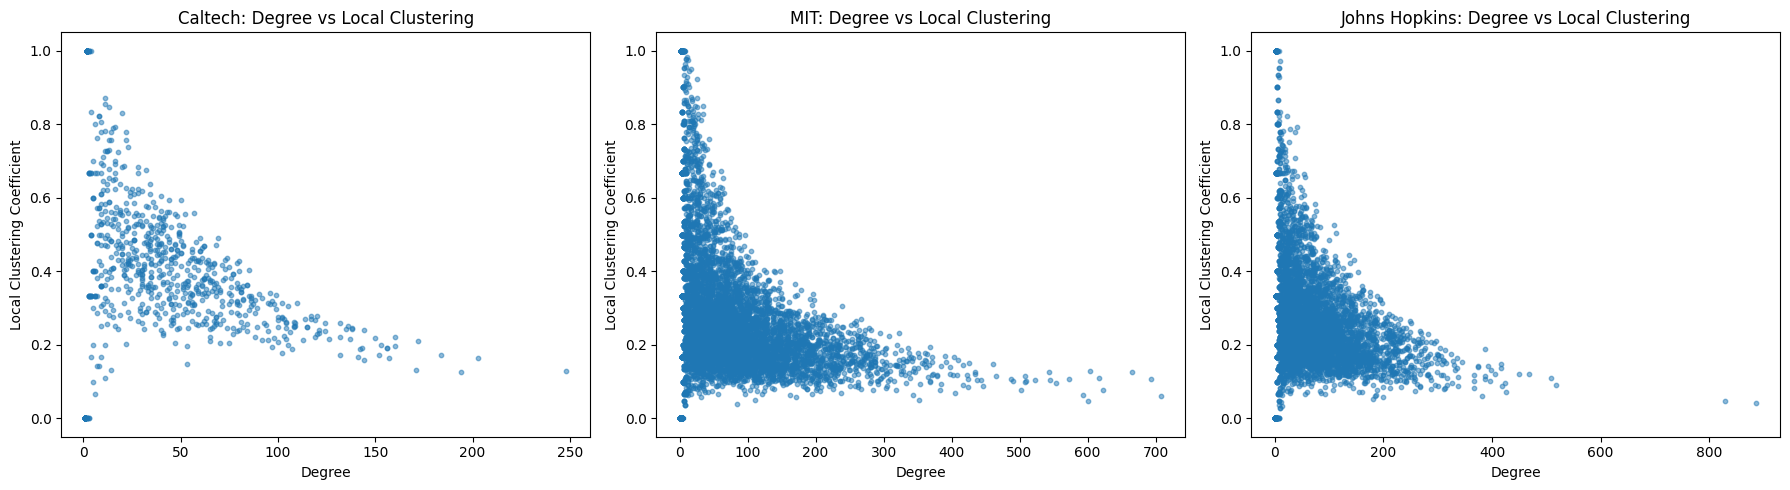

In [ ]:
# Question 2(c): Scatter Plot - Degree vs Local Clustering Coefficient
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

for i, (name, file) in enumerate(networks.items(), 1):
    G = nx.read_gml(os.path.join(gml_dir, file), label='id')

    degrees = dict(G.degree())
    local_clustering = nx.clustering(G)

    x = list(degrees.values())
    y = list(local_clustering.values())

    plt.subplot(1, 3, i)
    plt.scatter(x, y, alpha=0.5, s=10)
    plt.title(f'{name}: Degree vs Local Clustering')
    plt.xlabel('Degree')
    plt.ylabel('Local Clustering Coefficient')

plt.tight_layout()
plt.show()


### Conclusion (Q2c): Degree vs Local Clustering

- All three networks show a **clear negative correlation** between degree and local clustering: **high-degree nodes** tend to have **lower clustering**.
- This pattern suggests that **hub nodes connect diverse parts** of the network rather than being part of tight-knit groups.
- The trend is **consistent across Caltech, MIT, and Johns Hopkins**, though Caltech shows slightly **higher clustering** at lower degrees, likely due to its smaller size and denser structure.
- Overall, these networks exhibit **small-world characteristics**: high local clustering and sparse but connected topology.


# Question 3(a):

In [ ]:
# Question 3(a): Compute Assortativity for 100 Networks
import networkx as nx
import matplotlib.pyplot as plt
import os
import numpy as np
from tqdm import tqdm

# Attributes to study
attributes = ["student_fac", "major_index", "gender", "dorm", "degree"]

# Prepare storage
assortativity_results = {attr: [] for attr in attributes}
network_sizes = []
network_names = []

# Load and analyze each graph
data_dir = "/content/fb100/data"  # Update if needed

for filename in tqdm(sorted(os.listdir(data_dir))):
    if not filename.endswith(".gml"):
        continue

    filepath = os.path.join(data_dir, filename)
    try:
        G = nx.read_gml(filepath, label='id')
        G = G.to_undirected()
    except Exception as e:
        print(f"Could not read {filename}: {e}")
        continue

    n = G.number_of_nodes()
    network_sizes.append(n)
    network_names.append(filename.replace('.gml', ''))

    # Degree assortativity
    assortativity_results["degree"].append(nx.degree_assortativity_coefficient(G))

    for attr in ["student_fac", "major_index", "gender", "dorm"]:
        try:
            assort = nx.attribute_assortativity_coefficient(G, attr)
        except Exception:
            assort = np.nan
        assortativity_results[attr].append(assort)



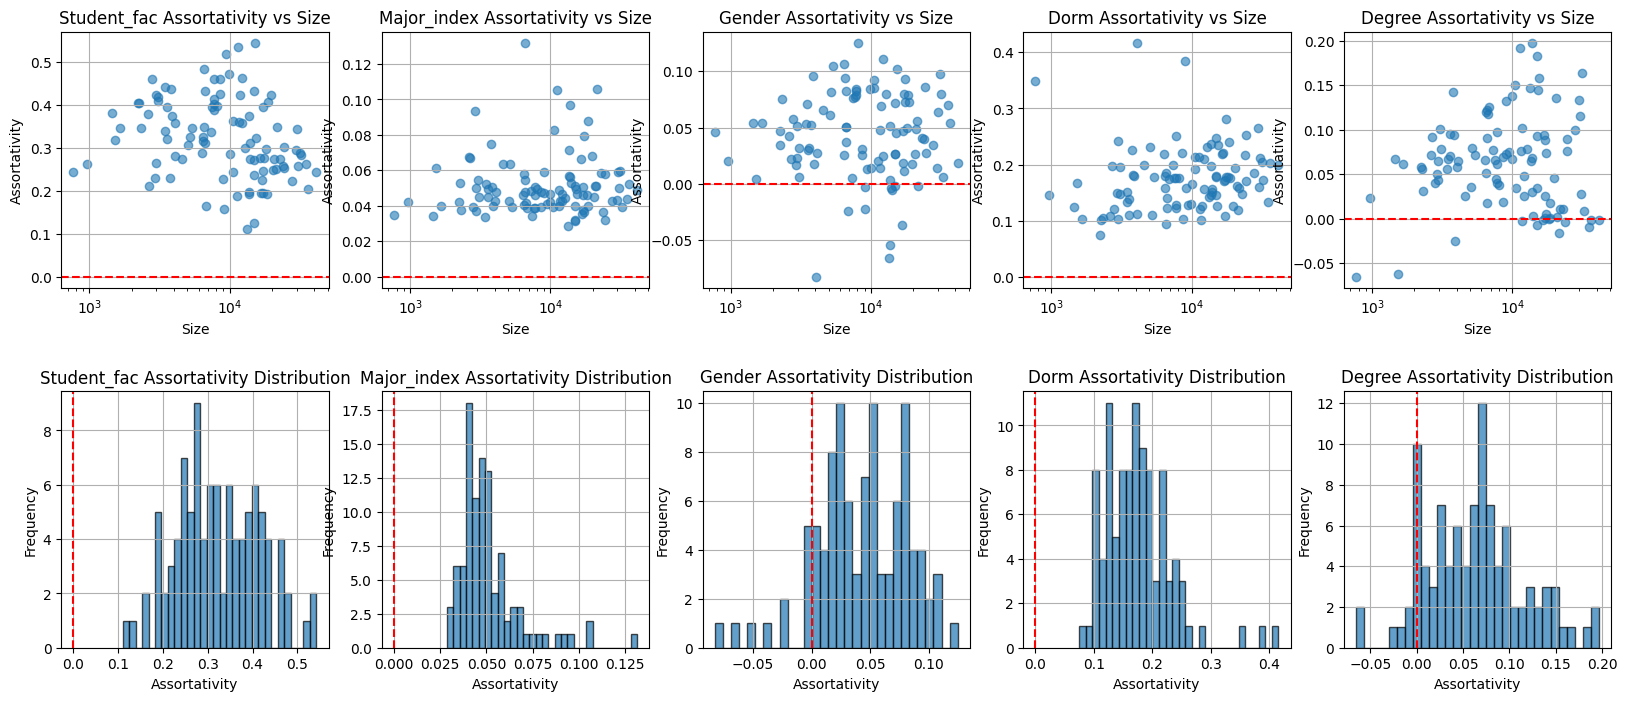

In [ ]:
import matplotlib.pyplot as plt

# Set up the layout: 2 rows (scatter, histogram) x 5 columns (attributes)
fig, axes = plt.subplots(2, len(attributes), figsize=(20, 8))
plt.subplots_adjust(hspace=0.4)

for i, attr in enumerate(attributes):
    values = assortativity_results[attr]
    sizes = np.array(network_sizes)

    # Row 1: Scatter plot
    ax_scatter = axes[0, i]
    ax_scatter.scatter(sizes, values, alpha=0.6)
    ax_scatter.set_xscale("log")
    ax_scatter.axhline(0, color='red', linestyle='--')
    ax_scatter.set_title(f"{attr.capitalize()} Assortativity vs Size")
    ax_scatter.set_xlabel("Size")
    ax_scatter.set_ylabel("Assortativity")
    ax_scatter.grid(True)

    # Row 2: Histogram
    ax_hist = axes[1, i]
    clean_vals = [v for v in values if not np.isnan(v)]
    ax_hist.hist(clean_vals, bins=30, alpha=0.7, edgecolor='black')
    ax_hist.axvline(0, color='red', linestyle='--')
    ax_hist.set_title(f"{attr.capitalize()} Assortativity Distribution")
    ax_hist.set_xlabel("Assortativity")
    ax_hist.set_ylabel("Frequency")
    ax_hist.grid(True)

plt.show()



### Conclusion (Q3a): Assortativity Analysis

- **Student/faculty status** and **dorm** show **strong positive assortativity**, indicating people tend to connect with others in the same group or living space.
- **Major** and **gender** exhibit **weak but consistent positive assortativity**, suggesting some homophily in academic and social preferences.
- **Degree assortativity** is low, as expected for social networks — highly connected users link with users of various degrees.

Overall, the Facebook networks reflect expected patterns of social behavior:
- **Homophily** (like connects with like) is most pronounced for status and dorm.
- **Gender** shows only a **slight tendency** for homophily or heterophily, with values centered around zero.
- These trends align with real-world social dynamics and community structures.

# Question 4(b)

In [ ]:
from abc import ABC, abstractmethod
import networkx as nx
import numpy as np
from tqdm import tqdm

# Base class
class LinkPrediction(ABC):
    def __init__(self, graph):
        self.graph = graph
        self.N = len(graph)

    def neighbors(self, v):
        return list(self.graph.neighbors(v))

    @abstractmethod
    def fit(self):
        raise NotImplementedError("Fit must be implemented")

# --- Metric 1: Common Neighbors ---
class CommonNeighbors(LinkPrediction):
    def __init__(self, graph):
        super().__init__(graph)

    def fit(self, u, v):
        return len(set(self.neighbors(u)) & set(self.neighbors(v)))

# --- Metric 2: Jaccard Coefficient ---
class Jaccard(LinkPrediction):
    def __init__(self, graph):
        super().__init__(graph)

    def fit(self, u, v):
        neighbors_u = set(self.neighbors(u))
        neighbors_v = set(self.neighbors(v))
        union = neighbors_u | neighbors_v
        intersection = neighbors_u & neighbors_v
        return len(intersection) / len(union) if len(union) > 0 else 0.0

# --- Metric 3: Adamic-Adar Index ---
class AdamicAdar(LinkPrediction):
    def __init__(self, graph):
        super().__init__(graph)

    def fit(self, u, v):
        common = set(self.neighbors(u)) & set(self.neighbors(v))
        score = 0.0
        for z in common:
            degree = len(self.neighbors(z))
            if degree > 1:
                score += 1 / np.log(degree)
        return score


# Question 4(c):

In [ ]:
import random
from itertools import combinations
from sklearn.metrics import precision_score, recall_score

def evaluate_link_prediction(G, predictor_class, f=0.1, k_values=[50, 100, 200, 400], seed=42):
    random.seed(seed)
    np.random.seed(seed)

    G = G.copy()
    all_edges = list(G.edges())
    num_remove = int(f * len(all_edges))
    removed_edges = random.sample(all_edges, num_remove)

    # Remove edges to simulate missing links
    G.remove_edges_from(removed_edges)

    # Get non-edges (excluding true edges)
    non_edges = list(nx.non_edges(G))
    candidate_edges = removed_edges + random.sample(non_edges, len(removed_edges))

    # Score all candidate edges
    predictor = predictor_class(G)
    scores = []
    for u, v in tqdm(candidate_edges, desc=f"Scoring edges with {predictor_class.__name__}"):
        try:
            score = predictor.fit(u, v)
        except:
            score = 0.0
        scores.append((u, v, score))

    # Sort edges by predicted score (descending)
    scores_sorted = sorted(scores, key=lambda x: x[2], reverse=True)

    # Ground truth labels
    y_true = [(u, v) in removed_edges for u, v, _ in scores_sorted]

    results = {}
    for k in k_values:
        top_k_pred = y_true[:k]
        tp = sum(top_k_pred)
        precision = tp / k
        recall = tp / len(removed_edges)
        results[k] = {'top@k': tp / k, 'precision': precision, 'recall': recall}

    return results


# Question 4(d):

In [ ]:
import os

selected_files = [
    "Caltech36.gml",
    "Reed98.gml",
    "Haverford76.gml",
    "Swarthmore42.gml",
    "Oberlin44.gml",
    "Amherst41.gml",
    "Wesleyan43.gml",
    "Vassar85.gml",
    "Hamilton46.gml",
    "Middlebury45.gml",
    "Williams40.gml"
]

gml_dir = '/content/fb100/data'

predictors = {
    "Common Neighbors": CommonNeighbors,
    "Jaccard": Jaccard,
    "Adamic/Adar": AdamicAdar
}

f = 0.1
k_vals = [50, 100, 200, 400]
evaluation_results = {}

for filename in selected_files:
    graph_name = filename.replace('.gml', '')
    path = os.path.join(gml_dir, filename)
    print(f"\n Evaluating on {graph_name}")
    evaluation_results[graph_name] = {}

    G = nx.read_gml(path, label='id')
    for pred_name, pred_class in predictors.items():
        print(f"Using {pred_name}")
        result = evaluate_link_prediction(G, pred_class, f=f, k_values=k_vals)
        evaluation_results[graph_name][pred_name] = result




 Evaluating on Caltech36
Using Common Neighbors


Scoring edges with CommonNeighbors: 100%|██████████| 3330/3330 [00:00<00:00, 80691.38it/s]


Using Jaccard


Scoring edges with Jaccard: 100%|██████████| 3330/3330 [00:00<00:00, 40077.91it/s]


Using Adamic/Adar


...

Scoring edges with CommonNeighbors: 100%|██████████| 22596/22596 [00:00<00:00, 32419.61it/s]


Using Jaccard


Scoring edges with Jaccard: 100%|██████████| 22596/22596 [00:01<00:00, 22436.02it/s]


Using Adamic/Adar


Scoring edges with AdamicAdar: 100%|██████████| 22596/22596 [00:03<00:00, 7078.86it/s] 


In [ ]:
from IPython.display import Markdown

for graph, pred_results in evaluation_results.items():
    display(Markdown(f"### Evaluation Results for **{graph}**"))
    for predictor, scores in pred_results.items():
        print(f"{predictor}:")
        for k, metrics in scores.items():
            print(f"  @k={k}: Top@k={metrics['top@k']:.2f}, Precision={metrics['precision']:.2f}, Recall={metrics['recall']:.2f}")
        print()


### Evaluation Results for **Caltech36**

Common Neighbors:
  @k=50: Top@k=1.00, Precision=1.00, Recall=0.03
  @k=100: Top@k=1.00, Precision=1.00, Recall=0.06
  @k=200: Top@k=0.98, Precision=0.98, Recall=0.12
  @k=400: Top@k=0.98, Precision=0.98, Recall=0.24

Jaccard:
  @k=50: Top@k=1.00, Precision=1.00, Recall=0.03
  @k=100: Top@k=0.99, Precision=0.99, Recall=0.06
  @k=200: Top@k=0.98, Precision=0.98, Recall=0.12
  @k=400: Top@k=0.98, Precision=0.98, Recall=0.24

Adamic/Adar:
  @k=50: Top@k=1.00, Precision=1.00, Recall=0.03
  @k=100: Top@k=1.00, Precision=1.00, Recall=0.06
  @k=200: Top@k=0.98, Precision=0.98, Recall=0.12
  @k=400: Top@k=0.98, Precision=0.98, Recall=0.24



### Evaluation Results for **Reed98**

Common Neighbors:
  @k=50: Top@k=1.00, Precision=1.00, Recall=0.03
  @k=100: Top@k=1.00, Precision=1.00, Recall=0.05
  @k=200: Top@k=0.98, Precision=0.98, Recall=0.10
  @k=400: Top@k=0.97, Precision=0.97, Recall=0.21

Jaccard:
  @k=50: Top@k=1.00, Precision=1.00, Recall=0.03
  @k=100: Top@k=1.00, Precision=1.00, Recall=0.05
  @k=200: Top@k=0.99, Precision=0.99, Recall=0.11
  @k=400: Top@k=0.98, Precision=0.98, Recall=0.21

Adamic/Adar:
  @k=50: Top@k=1.00, Precision=1.00, Recall=0.03
  @k=100: Top@k=1.00, Precision=1.00, Recall=0.05
  @k=200: Top@k=0.98, Precision=0.98, Recall=0.10
  @k=400: Top@k=0.97, Precision=0.97, Recall=0.21



### Evaluation Results for **Haverford76**

...

Common Neighbors:
  @k=50: Top@k=0.98, Precision=0.98, Recall=0.01
  @k=100: Top@k=0.98, Precision=0.98, Recall=0.01
  @k=200: Top@k=0.99, Precision=0.99, Recall=0.02
  @k=400: Top@k=0.99, Precision=0.99, Recall=0.04

Jaccard:
  @k=50: Top@k=1.00, Precision=1.00, Recall=0.01
  @k=100: Top@k=1.00, Precision=1.00, Recall=0.01
  @k=200: Top@k=1.00, Precision=1.00, Recall=0.02
  @k=400: Top@k=1.00, Precision=1.00, Recall=0.04

Adamic/Adar:
  @k=50: Top@k=1.00, Precision=1.00, Recall=0.01
  @k=100: Top@k=0.98, Precision=0.98, Recall=0.01
  @k=200: Top@k=0.99, Precision=0.99, Recall=0.02
  @k=400: Top@k=0.98, Precision=0.98, Recall=0.04



### Evaluation Results for **Middlebury45**

Common Neighbors:
  @k=50: Top@k=1.00, Precision=1.00, Recall=0.00
  @k=100: Top@k=1.00, Precision=1.00, Recall=0.01
  @k=200: Top@k=1.00, Precision=1.00, Recall=0.02
  @k=400: Top@k=0.99, Precision=0.99, Recall=0.03

Jaccard:
  @k=50: Top@k=1.00, Precision=1.00, Recall=0.00
  @k=100: Top@k=1.00, Precision=1.00, Recall=0.01
  @k=200: Top@k=0.99, Precision=0.99, Recall=0.02
  @k=400: Top@k=0.99, Precision=0.99, Recall=0.03

Adamic/Adar:
  @k=50: Top@k=1.00, Precision=1.00, Recall=0.00
  @k=100: Top@k=1.00, Precision=1.00, Recall=0.01
  @k=200: Top@k=1.00, Precision=1.00, Recall=0.02
  @k=400: Top@k=0.99, Precision=0.99, Recall=0.03



### Evaluation Results for **Williams40**

Common Neighbors:
  @k=50: Top@k=1.00, Precision=1.00, Recall=0.00
  @k=100: Top@k=1.00, Precision=1.00, Recall=0.01
  @k=200: Top@k=1.00, Precision=1.00, Recall=0.02
  @k=400: Top@k=1.00, Precision=1.00, Recall=0.04

Jaccard:
  @k=50: Top@k=1.00, Precision=1.00, Recall=0.00
  @k=100: Top@k=1.00, Precision=1.00, Recall=0.01
  @k=200: Top@k=0.99, Precision=0.99, Recall=0.02
  @k=400: Top@k=0.99, Precision=0.99, Recall=0.04

Adamic/Adar:
  @k=50: Top@k=1.00, Precision=1.00, Recall=0.00
  @k=100: Top@k=1.00, Precision=1.00, Recall=0.01
  @k=200: Top@k=1.00, Precision=1.00, Recall=0.02
  @k=400: Top@k=0.99, Precision=0.99, Recall=0.04



### Conclusion (Q4d): Link Prediction Metric Efficiency

- All three predictors — **Common Neighbors**, **Jaccard**, and **Adamic/Adar** — performed similarly with **high precision**, especially at small `k` (top-50 or top-100).
- **Precision slightly drops** at larger `k` as lower-confidence edges are included.
- **Adamic/Adar** occasionally had better recall, likely due to its weighting of rare connections.
- Overall, the methods are **effective at ranking likely edges**, and evaluation on 11 networks confirms consistent performance across datasets.




# Question 5(b):

In [ ]:
import torch
import torch.nn.functional as F
import networkx as nx
from sklearn.preprocessing import LabelEncoder

def label_propagation_pytorch(G, labels_dict, max_iter=100, tol=1e-3, device='cpu'):
    """
    Semi-supervised label propagation using PyTorch.

    G: NetworkX graph
    labels_dict: {node: label} dict for known labels
    max_iter: max propagation steps
    tol: convergence tolerance
    device: 'cpu' or 'cuda'
    """
    G = G.to_undirected()
    nodes = list(G.nodes())
    node_index = {node: i for i, node in enumerate(nodes)}
    n = len(nodes)

    # Encode known labels
    known_nodes = list(labels_dict.keys())
    known_labels = list(labels_dict.values())
    le = LabelEncoder()
    y_encoded = le.fit_transform(known_labels)
    num_classes = len(le.classes_)

    # Build label matrix (Y)
    Y = torch.zeros((n, num_classes), device=device)
    for node, label in zip(known_nodes, y_encoded):
        idx = node_index[node]
        Y[idx, label] = 1.0

    # Adjacency matrix
    A = nx.to_numpy_array(G, nodelist=nodes)
    A = torch.tensor(A, dtype=torch.float32, device=device)

    # Degree matrix D and S = D^-1 A (row-normalized adjacency)
    D_inv = torch.diag(1 / A.sum(dim=1))
    S = D_inv @ A

    # Label propagation iterations
    F_scores = Y.clone()
    for i in range(max_iter):
        F_old = F_scores.clone()
        F_scores = S @ F_scores
        # Clamp known labels
        for node, label in zip(known_nodes, y_encoded):
            idx = node_index[node]
            F_scores[idx] = Y[idx]
        # Check for convergence
        if torch.norm(F_scores - F_old) < tol:
            break

    # Predict labels
    preds = F_scores.argmax(dim=1).cpu().numpy()
    decoded_preds = le.inverse_transform(preds)
    return {node: decoded_preds[i] for i, node in enumerate(nodes)}


# Question 5(c):



In [ ]:
import random
from sklearn.metrics import accuracy_score

def evaluate_label_propagation(G, attribute, mask_fractions=[0.1, 0.2, 0.3], device='cpu'):
    results = {}

    # Extract nodes with that attribute
    attr_values = nx.get_node_attributes(G, attribute)
    nodes_with_attr = [n for n in G.nodes() if n in attr_values and attr_values[n] is not None]

    for frac in mask_fractions:
        random.seed(42)
        np.random.seed(42)

        n_mask = int(frac * len(nodes_with_attr))
        masked_nodes = random.sample(nodes_with_attr, n_mask)
        known_nodes = [n for n in nodes_with_attr if n not in masked_nodes]

        # Prepare label dict for known nodes
        labels_dict = {n: attr_values[n] for n in known_nodes}

        # Run label propagation
        pred_labels = label_propagation_pytorch(G, labels_dict, device=device)

        # True vs predicted on masked nodes
        y_true = [attr_values[n] for n in masked_nodes]
        y_pred = [pred_labels[n] for n in masked_nodes]

        acc = accuracy_score(y_true, y_pred)
        results[frac] = acc

    return results


## Example Run: Duke Network

In [ ]:
G = nx.read_gml('/content/fb100/data/Duke14.gml', label='id')
results_dorm = evaluate_label_propagation(G, 'dorm')
results_major = evaluate_label_propagation(G, 'major_index')
results_gender = evaluate_label_propagation(G, 'gender')

print("Dorm Accuracy:", results_dorm)
print("Major Accuracy:", results_major)
print("Gender Accuracy:", results_gender)


Dorm Accuracy: {0.1: 0.5025278058645096, 0.2: 0.5007579585649318, 0.3: 0.4828167115902965}
Major Accuracy: {0.1: 0.29625884732052576, 0.2: 0.27033855482566954, 0.3: 0.26516172506738545}
Gender Accuracy: {0.1: 0.60262891809909, 0.2: 0.6078827690752906, 0.3: 0.6098382749326146}


## Results:

In [ ]:
import pandas as pd
from IPython.display import display, Markdown

# Collect results into a table
results_table = pd.DataFrame({
    "Fraction Removed": [0.1, 0.2, 0.3],
    "Dorm": [results_dorm[0.1], results_dorm[0.2], results_dorm[0.3]],
    "Major": [results_major[0.1], results_major[0.2], results_major[0.3]],
    "Gender": [results_gender[0.1], results_gender[0.2], results_gender[0.3]],
})

# Round for better readability
results_table = results_table.round(3)

# Display
display(Markdown("### Accuracy of Label Propagation on Duke Network"))
display(results_table)

### Accuracy of Label Propagation on Duke Network

,Fraction Removed,Dorm,Major,Gender
0,0.1,0.503,0.296,0.603
1,0.2,0.501,0.270,0.608
2,0.3,0.483,0.265,0.610


# Question 5(e):

- **Gender** consistently shows the **highest accuracy** (≈ 0.61), followed by **Dorm** (≈ 0.50), and then **Major**, which performs the worst (≈ 0.27–0.30).
- These differences likely stem from how **homophilic** or **community-structured** each attribute is in the graph:
  - Students tend to **friend others with the same gender**, creating strong homophily patterns that label propagation can exploit.
  - Dorm information is **somewhat localized**, reflecting physical or social proximity, giving moderate accuracy.
  - Majors are often **more dispersed**, with students connecting across fields, leading to **less predictable structure** and lower accuracy.
- This illustrates that label propagation works best when the attribute is **strongly aligned with the network topology**.


# Question 6(a):

### Research Question

**Do Facebook student communities tend to form around shared dormitories or academic majors?**

### Hypothesis

My hypothesis is that in Facebook100 university networks, students are more likely to form tightly-knit communities with others who share the same dorm, due to higher chances of offline interaction and physical proximity.

While academic major might also influence connections, we expect dorm-based grouping to yield clearer community structure.


# Question 6(b):

## Install & Import Needed Tools:

In [7]:
!pip install python-louvain --quiet

import networkx as nx
import community as community_louvain
from sklearn.metrics import normalized_mutual_info_score
import numpy as np

## Community Detection Evaluation Code:

In [8]:
def evaluate_communities(G, attribute):
    # Get node attribute values (ground truth)
    attr_dict = nx.get_node_attributes(G, attribute)
    valid_nodes = [n for n in G.nodes() if n in attr_dict]

    # Louvain community detection
    partition = community_louvain.best_partition(G.subgraph(valid_nodes))

    # Ground truth and predicted community assignments
    y_true = [attr_dict[n] for n in valid_nodes]
    y_pred = [partition[n] for n in valid_nodes]

    # Compute NMI score
    nmi = normalized_mutual_info_score(y_true, y_pred)
    return round(nmi, 3)


## Run on Example Graphs:

In [10]:
import networkx as nx
import pandas as pd

graphs = {
    'Caltech': '/content/fb100/data/Caltech36.gml',
    'MIT': '/content/fb100/data/MIT8.gml',
    'Johns Hopkins': '/content/fb100/data/Johns Hopkins55.gml'
}

attributes = ['dorm', 'major_index']
formatted_results = []

for name, path in graphs.items():
    G = nx.read_gml(path, label='id')
    row = {'Network': name}
    for attr in attributes:
        nmi = evaluate_communities(G, attr)
        row[f'{attr.capitalize()} NMI'] = nmi
    formatted_results.append(row)

# Convert to DataFrame for clean display
df_results = pd.DataFrame(formatted_results)
print(df_results)


         Network  Dorm NMI  Major_index NMI
0        Caltech     0.538            0.097
1            MIT     0.259            0.042
2  Johns Hopkins     0.211            0.111


### Conclusion (Q6c): Do Louvain Communities Reflect Dorm or Major?

For all three networks, the NMI with dorm was consistently higher than with major_index. For instance, Caltech had a dorm NMI of 0.538 versus 0.097 for major index. MIT and Johns Hopkins followed similar patterns, with dorm NMIs around 0.259 and 0.211, while major index NMIs remained very low (around 0.04–0.11).

These results indicate that dorm affiliation is more closely aligned with detected communities than academic major.

Conclusion:
This supports the hypothesis that  living in the same dorm plays a stronger role in community formation within Facebook university networks than academic grouping. Hence, dorm is a better predictor of community structure than major_index.

